## Step 1: Environment Setup
Import required libraries and configure display settings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option('display.max_columns', 100)
print('All libraries loaded successfully!')

All libraries loaded successfully!


In [ ]:
# Load dataset
df = pd.read_csv('hotel_bookings.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()



Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Step 2: Initial Data Understanding
Quickly inspect structure, data types, missing values, and target distribution.

In [3]:
# Verify dataset is loaded
print('Dataset shape:', df.shape)
print('\nFirst few rows:')
display(df.head())

Dataset shape: (119390, 32)

First few rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Data types and info
print('Data types and null counts:')
df.info()

Data types and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  i

In [5]:
# Missing values analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing values (top 15):')
display(missing_table[missing_table['missing_count'] > 0].head(15))

Missing values (top 15):


,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


Target variable (is_canceled) distribution:


,count,percentage
is_canceled,,
0,75166,62.958372
1,44224,37.041628


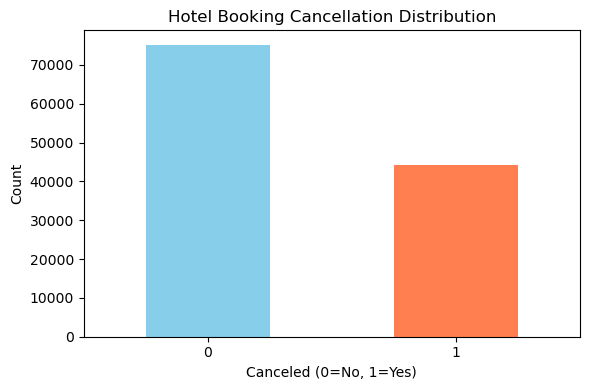


Dataset loaded and inspected


In [6]:
# Target variable distribution
print('Target variable (is_canceled) distribution:')
target_counts = df['is_canceled'].value_counts()
target_pct = df['is_canceled'].value_counts(normalize=True) * 100
target_table = pd.DataFrame({'count': target_counts, 'percentage': target_pct})
display(target_table)

plt.figure(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Hotel Booking Cancellation Distribution')
plt.xlabel('Canceled (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nDataset loaded and inspected')

## Step 3: Data Preprocessing
Handle missing values, remove leakage columns, and prepare feature groups.

In [7]:
# Handle missing values
df_clean = df.copy()

df_clean['children'] = df_clean['children'].fillna(df_clean['children'].median())
df_clean['country'] = df_clean['country'].fillna(df_clean['country'].mode()[0])
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['company'] = df_clean['company'].fillna(0)

print('Remaining missing values:', df_clean.isnull().sum().sum())
print('\nMissing values handled successfully')

Remaining missing values: 0

Missing values handled successfully


In [8]:
# Remove leakage columns (known only after booking outcome)
df_clean = df_clean.drop(['reservation_status', 'reservation_status_date'], axis=1)

print('Leakage columns removed')
print('Remaining columns:', df_clean.shape[1])

Leakage columns removed
Remaining columns: 30


In [9]:
# Identify categorical and numerical columns
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = df_clean.select_dtypes(exclude=['object', 'string']).drop('is_canceled', axis=1).columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numerical columns:', len(num_cols))

print('\nPreprocessing complete. Ready for modeling.')

Categorical columns: 10
Numerical columns: 19

Preprocessing complete. Ready for modeling.


## Step 4: Modeling Setup
Define features and target, perform stratified split, and train baseline Decision Tree pipeline.

In [10]:
# Define features (X) and target (y)
X = df_clean.drop('is_canceled', axis=1)
y = df_clean['is_canceled']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nTarget distribution:')
print(y.value_counts())
print('\nTarget proportions:')
print(y.value_counts(normalize=True))

Features shape: (119390, 29)
Target shape: (119390,)

Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target proportions:
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


In [11]:
# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])
print('\nTraining set target distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest set target distribution:')
print(y_test.value_counts(normalize=True))

Training set size: 95512
Test set size: 23878

Training set target distribution:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Test set target distribution:
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


In [12]:
# Build preprocessing pipeline
num_cols_final = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()
cat_cols_final = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_final),
        ('num', 'passthrough', num_cols_final)
    ]
)

baseline_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print('Baseline Decision Tree model trained successfully!')

Baseline Decision Tree model trained successfully!


## Step 5: Baseline Evaluation
Measure baseline model performance using metrics and confusion matrix.

In [13]:
# Baseline metrics
acc_base = accuracy_score(y_test, y_pred_base)
pre_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print('Baseline Accuracy :', round(acc_base, 4))
print('Baseline Precision:', round(pre_base, 4))
print('Baseline Recall   :', round(rec_base, 4))
print('Baseline F1-Score :', round(f1_base, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=['Not Cancelled', 'Cancelled']))

Baseline Accuracy : 0.8597
Baseline Precision: 0.8097
Baseline Recall   : 0.812
Baseline F1-Score : 0.8108

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.89      0.89      0.89     15033
    Cancelled       0.81      0.81      0.81      8845

     accuracy                           0.86     23878
    macro avg       0.85      0.85      0.85     23878
 weighted avg       0.86      0.86      0.86     23878



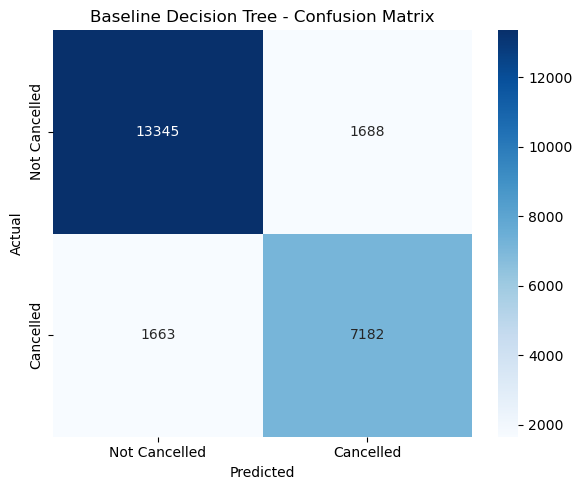

Step 5 complete: Baseline model evaluated


In [14]:
# Confusion matrix visualization
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title('Baseline Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Step 5 complete: Baseline model evaluated')